<a href="https://colab.research.google.com/github/rifatz-the-analyst/Retail-Sales-Inventory-Optimization-Analysis/blob/main/Maven_Toys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Library**

In [64]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df_products = pd.read_csv('/content/drive/MyDrive/Portofolio/Maven Toys/products.csv')
df_stores = pd.read_csv('/content/drive/MyDrive/Portofolio/Maven Toys/stores.csv')
df_inventory = pd.read_csv('/content/drive/MyDrive/Portofolio/Maven Toys/inventory.csv')
df_calendar = pd.read_csv('/content/drive/MyDrive/Portofolio/Maven Toys/calendar.csv')
df_sales = pd.read_csv('/content/drive/MyDrive/Portofolio/Maven Toys/sales.csv')

# **Data Profiling**

**Revenue Describe**

In [66]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sales_id       829262 non-null  int64  
 1   date           829262 non-null  object 
 2   store_id       829262 non-null  int64  
 3   product_id     829262 non-null  int64  
 4   units          829262 non-null  int64  
 5   product_cost   829262 non-null  float64
 6   product_price  829262 non-null  float64
 7   cogs           829262 non-null  float64
 8   revenue        829262 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 56.9+ MB


In [67]:
df_sales['revenue'].describe()

,revenue
count,829262.000000
mean,17.431738
std,15.526597
min,3.000000
25%,9.000000
50%,15.000000
75%,20.000000
max,880.000000


In [102]:
pctile = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
revenue_percentiles = df_sales['revenue'].quantile(pctile)

revenue_percentiles

,revenue
0.10,5.0
0.25,9.0
0.50,15.0
0.75,20.0
0.90,40.0
0.95,42.0


In [69]:
q1 = df_sales['revenue'].quantile(0.25)
q3 = df_sales['revenue'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 9.0
Q3: 20.0
IQR: 11.0
Lower Bound: -7.5
Upper Bound: 36.5


**Outlier Identificatons**

In [70]:
upper_outliers = df_sales[df_sales['revenue'] > upper_bound]
lower_outliers = df_sales[df_sales['revenue'] < lower_bound]

upper_outliers_count = len(upper_outliers)
lower_outliers_count = len(lower_outliers)

print("Upper Outliers Count:", upper_outliers_count)
print("Lower Outliers Count:", lower_outliers_count)
print("Outlier Percentage:", (upper_outliers_count + lower_outliers_count) / len(df_sales) * 100)

Upper Outliers Count: 89908
Lower Outliers Count: 0
Outlier Percentage: 10.841929329934327


In [101]:
upper_outliers_frequency = upper_outliers['revenue'].value_counts().sort_index()
upper_outliers_percentage = upper_outliers['revenue'].value_counts(normalize=True).sort_index() * 100

print("Upper Outliers:")
print(upper_outliers_frequency)
print("Upper Outliers Percentage:")
print(upper_outliers_percentage)

Upper Outliers:
revenue
39.0      2242
40.0     45386
42.0      1179
44.0      1157
45.0     10193
         ...  
720.0        1
760.0        1
800.0        2
840.0        2
880.0        1
Name: count, Length: 87, dtype: int64
Upper Outliers Percentage:
revenue
39.0      2.493660
40.0     50.480491
42.0      1.311340
44.0      1.286871
45.0     11.337145
           ...    
720.0     0.001112
760.0     0.001112
800.0     0.002224
840.0     0.002224
880.0     0.001112
Name: proportion, Length: 87, dtype: float64


**Revenue Frequency**

In [72]:
revenue_frequency = df_sales['revenue'].value_counts().sort_values()
revenue_frequency_percentage = df_sales['revenue'].value_counts(normalize=True).sort_values() * 100

print("Revenue Frequency:")
print(revenue_frequency)
print("Revenue Frequency Percentage:")
print(revenue_frequency_percentage)

Revenue Frequency:
revenue
336.0        1
304.0        1
880.0        1
760.0        1
297.0        1
         ...  
40.0     45386
7.0      59015
15.0     84004
20.0     87502
16.0     96401
Name: count, Length: 115, dtype: int64
Revenue Frequency Percentage:
revenue
336.0     0.000121
304.0     0.000121
880.0     0.000121
760.0     0.000121
297.0     0.000121
           ...    
40.0      5.473059
7.0       7.116569
15.0     10.129971
20.0     10.551792
16.0     11.624915
Name: proportion, Length: 115, dtype: float64


**Investigate Product with the Revenue of 16**

In [73]:
product_revenue_16 = df_sales[df_sales['revenue'] == 16]

product_revenue_16 = product_revenue_16[['sales_id','date','product_id','units','product_price','revenue']].sort_values(by='units', ascending=False)

print(product_revenue_16.groupby('product_id')['product_id'].count().reset_index(name='count'))

   product_id  count
0           1  42752
1           3   2524
2           7  22896
3          19  28196
4          35     33


In [74]:
product_investigate = df_products.merge(product_revenue_16, on='product_id', how='inner')

product_investigate.groupby(['product_name','product_category'])['product_name'].count().reset_index(name='count')

,product_name,product_category,count
0,Action Figure,Toys,42752
1,Barrel O' Slime,Art & Crafts,2524
2,Dart Gun,Sports & Outdoors,22896
3,Magic Sand,Art & Crafts,28196
4,Uno Card Game,Games,33


**Unit Sold Describe**

In [75]:
df_sales['units'].describe()

,units
count,829262.000000
mean,1.315103
std,0.830701
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,30.000000


In [76]:
q1 = df_sales['units'].quantile(0.25)
q3 = df_sales['units'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.0
Q3: 1.0
IQR: 0.0
Lower Bound: 1.0
Upper Bound: 1.0


**Unit Sold Frequency**

In [77]:
unit_frequency = df_sales['units'].value_counts().sort_values()
unit_frequency_percentage = df_sales['units'].value_counts(normalize=True).sort_values() * 100

print("Unit Frequency:")
print(unit_frequency)
print("Unit Frequency Percentage:")
print(unit_frequency_percentage)

Unit Frequency:
units
27         1
25         1
30         2
23         5
24         7
22         7
14         9
18        10
20        10
19        11
21        12
16        12
17        13
15        18
13        25
12        35
11        36
10        96
8        180
9        203
7        779
5       2628
6       2808
4      13117
2      54576
3      65638
1     689023
Name: count, dtype: int64
Unit Frequency Percentage:
units
27     0.000121
25     0.000121
30     0.000241
23     0.000603
24     0.000844
22     0.000844
14     0.001085
18     0.001206
20     0.001206
19     0.001326
21     0.001447
16     0.001447
17     0.001568
15     0.002171
13     0.003015
12     0.004221
11     0.004341
10     0.011577
8      0.021706
9      0.024480
7      0.093939
5      0.316908
6      0.338614
4      1.581768
2      6.581273
3      7.915231
1     83.088698
Name: proportion, dtype: float64


**Price Frequency**

In [78]:
price_frequency = df_sales['product_price'].value_counts().sort_values()
price_frequency_percentage = df_sales['product_price'].value_counts(normalize=True).sort_values() * 100

print("Price Frequency:")
print(price_frequency)
print("Price Frequency Percentage:")
print(price_frequency_percentage)

Price Frequency:
product_price
8.0       2599
12.0      6812
25.0      8649
26.0     10494
5.0      20736
6.0      20776
21.0     26748
9.0      41559
13.0     41984
40.0     48030
10.0     48610
4.0      54078
11.0     55500
3.0      64834
7.0      68083
20.0     92390
15.0    103387
16.0    113993
Name: count, dtype: int64
Price Frequency Percentage:
product_price
8.0      0.313411
12.0     0.821453
25.0     1.042976
26.0     1.265463
5.0      2.500537
6.0      2.505360
21.0     3.225519
9.0      5.011564
13.0     5.062815
40.0     5.791897
10.0     5.861839
4.0      6.521220
11.0     6.692698
3.0      7.818277
7.0      8.210071
20.0    11.141232
15.0    12.467350
16.0    13.746319
Name: proportion, dtype: float64


**Revenue Upper Outlier**

In [79]:
print("Upper Outliers:")
print(upper_outliers[['sales_id','date','product_id','units','product_price','revenue']].sort_values(by='revenue', ascending=False).head(20))
print("\nLower Outliers:")
print(lower_outliers[['sales_id','date','product_id','units','product_price','revenue']].sort_values(by='revenue').head(20))

Upper Outliers:
        sales_id        date  product_id  units  product_price  revenue
516427    516428  2023-03-10          18     22           40.0    880.0
517671    517672  2023-03-10          18     21           40.0    840.0
518096    518097  2023-03-10          18     21           40.0    840.0
516618    516619  2023-03-10          18     20           40.0    800.0
516434    516435  2023-03-10          18     20           40.0    800.0
516398    516399  2023-03-10          18     19           40.0    760.0
517599    517600  2023-03-10          18     18           40.0    720.0
518074    518075  2023-03-10          18     17           40.0    680.0
516110    516111  2023-03-10          18     17           40.0    680.0
516461    516462  2023-03-10          18     17           40.0    680.0
517059    517060  2023-03-10          18     16           40.0    640.0
516535    516536  2023-03-10          18     16           40.0    640.0
516975    516976  2023-03-10          18     15 

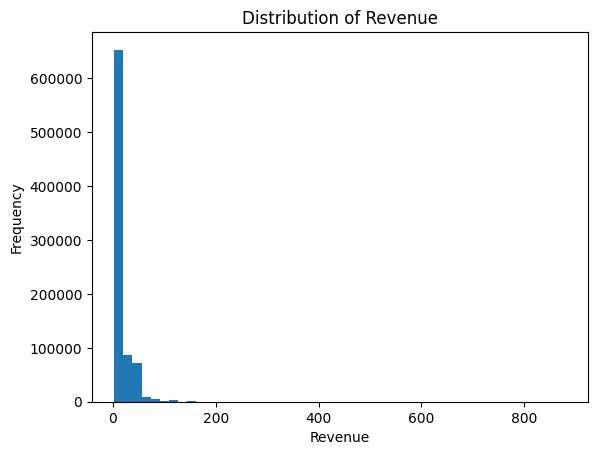

In [80]:
plt.hist(df_sales['revenue'], bins=50)
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.title('Distribution of Revenue')
plt.show()

# **Data Merging and Formating**

**Create analysis table**

In [81]:
products_subset = df_products[['product_id', 'product_category', 'product_name']]
analysis_table = df_sales.merge(products_subset,how="inner", on="product_id")
analysis_table = analysis_table.merge(df_stores,how="inner", on="store_id")

**Feature Engineering**

In [82]:
analysis_table["date"] = pd.to_datetime(analysis_table["date"])
analysis_table["year"] = analysis_table["date"].dt.year
analysis_table["month"] = analysis_table["date"].dt.month
analysis_table["profit"] = analysis_table["revenue"] - analysis_table["cogs"]

In [83]:
analysis_table

,sales_id,date,store_id,product_id,units,product_cost,product_price,cogs,revenue,product_category,product_name,store_name,store_city,store_location,store_open_date,year,month,profit
0,1,2022-01-01,24,4,1,10.0,13.0,10.0,13.0,Games,Chutes & Ladders,Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,2022,1,3.0
1,2,2022-01-01,28,1,1,10.0,16.0,10.0,16.0,Toys,Action Figure,Puebla 2,Puebla,Downtown,2011-04-01,2022,1,6.0
2,3,2022-01-01,6,8,1,4.0,7.0,4.0,7.0,Games,Deck Of Cards,Mexicali 1,Mexicali,Commercial,2003-12-13,2022,1,3.0
3,4,2022-01-01,48,7,1,12.0,16.0,12.0,16.0,Sports & Outdoors,Dart Gun,Saltillo 2,Saltillo,Commercial,2016-03-23,2022,1,4.0
4,5,2022-01-01,44,18,1,35.0,40.0,35.0,40.0,Toys,Lego Bricks,Puebla 3,Puebla,Residential,2014-12-27,2022,1,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829257,829258,2023-09-30,24,19,1,14.0,16.0,14.0,16.0,Art & Crafts,Magic Sand,Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,2023,9,2.0
829258,829259,2023-09-30,16,35,1,4.0,8.0,4.0,8.0,Games,Uno Card Game,San Luis Potosi 1,San Luis Potosi,Downtown,2007-05-19,2023,9,4.0
829259,829260,2023-09-30,22,19,1,14.0,16.0,14.0,16.0,Art & Crafts,Magic Sand,Guanajuato 2,Guanajuato,Commercial,2010-03-29,2023,9,2.0
829260,829261,2023-09-30,13,2,2,10.0,13.0,20.0,26.0,Toys,Animal Figures,Mexicali 2,Mexicali,Downtown,2006-08-30,2023,9,6.0


# **Product Analysis**

**Revenue Monthly Trend**

In [84]:
revenue_by_month = analysis_table.groupby(["year","month"])["revenue"].sum()
revenue_monthly_growth = round(revenue_by_month.pct_change()*100,2)
revenue_monthly_growth

year  month
2022  1          NaN
      2        -0.22
      3         8.89
      4        15.54
      5        -1.28
      6        -1.54
      7       -15.99
      8       -11.98
      9        19.69
      10        6.50
      11        6.00
      12       32.64
2023  1       -14.82
      2        -3.29
      3        22.27
      4        -6.32
      5        -0.29
      6        -2.06
      7         2.48
      8       -20.22
      9        -0.40
Name: revenue, dtype: float64

**Category Performance**

In [85]:
category_performance = (
    analysis_table.groupby("product_category")
    .agg(
        total_revenue=("revenue","sum"),
        total_profit=("profit","sum")
    )
)
category_total_revenue = category_performance["total_revenue"].sum()
category_performance["revenue_contribution"] = round(category_performance["total_revenue"]/category_total_revenue*100,2)
category_total_profit = category_performance["total_profit"].sum()
category_performance["profit_contribution"] = round(category_performance["total_profit"]/category_total_profit*100,2)

category_performance

,total_revenue,total_profit,revenue_contribution,profit_contribution
product_category,,,,
Art & Crafts,2708620.0,753354.0,18.74,18.77
Electronics,2248112.0,1001437.0,15.55,24.95
Games,2228783.0,673993.0,15.42,16.79
Sports & Outdoors,2174050.0,505718.0,15.04,12.60
Toys,5095913.0,1079527.0,35.25,26.89


**Product Contribution in Category**

In [86]:
product_performance_in_category = (
    analysis_table
    .groupby(["product_category","product_name"])[["revenue","profit"]]
    .sum()
).reset_index()

category_total_metrics = (
    product_performance_in_category
    .groupby("product_category")[["revenue","profit"]]
    .transform("sum")
)

product_performance_in_category[["category_revenue","category_profit"]] = category_total_metrics
product_performance_in_category["revenue_contribution"] = (
    round(product_performance_in_category["revenue"]/product_performance_in_category["category_revenue"]*100,2)
)

product_performance_in_category["profit_contribution"] = (
    round(product_performance_in_category["profit"]/product_performance_in_category["category_profit"]*100,2)
)

summary_product_in_category = (
    product_performance_in_category
    [["product_category","product_name","revenue_contribution","profit_contribution"]]
)

summary_product_in_category

,product_category,product_name,revenue_contribution,profit_contribution
0,Art & Crafts,Barrel O' Slime,13.54,24.33
1,Art & Crafts,Etch A Sketch,9.43,16.15
2,Art & Crafts,Kids Makeup Kit,18.04,19.46
3,Art & Crafts,Magic Sand,35.80,16.09
4,Art & Crafts,PlayDoh Can,11.42,13.69
5,Art & Crafts,PlayDoh Playset,5.81,3.34
6,Art & Crafts,PlayDoh Toolkit,4.27,3.07
7,Art & Crafts,Playfoam,1.69,3.86
8,Electronics,Colorbuds,69.64,83.37
9,Electronics,Gamer Headphones,16.77,10.76


**Product Performance**

In [87]:
product_performance = (
    analysis_table.groupby("product_name")
    .agg(
        total_revenue=("revenue","sum"),
        total_profit=("profit","sum")
    )
)
product_total_revenue = product_performance["total_revenue"].sum()
product_performance["revenue_contribution"] = round(product_performance["total_revenue"]/product_total_revenue*100,2)
product_total_profit = product_performance["total_profit"].sum()
product_performance["profit_contribution"] = round(product_performance["total_profit"]/product_total_profit*100,2)
product_performance = product_performance.sort_values("revenue_contribution",ascending=False)

product_performance

,total_revenue,total_profit,revenue_contribution,profit_contribution
product_name,,,,
Lego Bricks,2389480.0,298685.0,16.53,7.44
Colorbuds,1565520.0,834944.0,10.83,20.80
Magic Sand,969568.0,121196.0,6.71,3.02
Action Figure,927328.0,347748.0,6.42,8.66
Rubik's Cube,913440.0,91344.0,6.32,2.28
Deck Of Cards,588238.0,252102.0,4.07,6.28
Splash Balls,542232.0,60248.0,3.75,1.50
Nerf Gun,530860.0,132715.0,3.67,3.31
Animal Figures,508157.0,117267.0,3.52,2.92


**Product Revenue Monthly Growth**

In [88]:
monthly_product_performance = analysis_table.pivot_table(
    index=["year","month"],
    columns="product_name",
    values="revenue",
    aggfunc="sum"
)
monthly_product_growth = round(monthly_product_performance.pct_change()*100,2)

monthly_product_growth

/tmp/ipykernel_3558/974701218.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_product_growth = round(monthly_product_performance.pct_change()*100,2)


product_name  Action Figure  Animal Figures  Barrel O' Slime  \
year month                                                     
2022 1                  NaN             NaN              NaN   
     2                -8.60           26.37           -76.32   
     3                15.23           -0.47             0.00   
     4                 2.24           13.77             0.00   
     5                -3.16           -0.79             0.00   
     6                 6.27            0.61             0.00   
     7               -17.34           -1.71            11.11   
     8               -14.24          -32.82          4745.00   
     9               -13.98          -12.40           338.39   
     10                8.52           57.76            78.30   
     11               -2.70            0.66            14.29   
     12                4.32          -13.35             2.47   
2023 1               -11.21          -16.34           -12.53   
     2               -10.33           -1.04             5.57   
     3                59.93           40.59            22.83   
     4               -17.57          -14.74           -20.34   
     5                -0.30           21.09           -20.70   
     6                19.81           -2.42             2.66   
     7               -52.41            8.38           -17.55   
     8                 3.40          -11.39           -31.38   
     9                 5.19            4.80            42.28   

product_name  Chutes & Ladders  Classic Dominoes  Colorbuds  Dart Gun  \
year month                                                              
2022 1                     NaN               NaN        NaN       NaN   
     2                  -77.71            -26.45      -5.96     -1.14   
     3                  -54.05            -17.73       2.83      3.13   
     4                   11.76             73.65      -7.34      5.39   
     5                  -73.68            -42.76      -4.03    -14.12   
     6                 3380.00             50.00      -6.71     34.86   
     7                   25.29            -13.25       0.08     -6.49   
     8                    5.96             -1.39      -2.20    -26.36   
     9                  -27.71            -25.82     -22.57     12.16   
     10                  -1.20            -27.22      -4.42     -9.35   
     11                  59.39             19.13      -9.10     10.32   
     12                  78.71            140.88      -4.81     19.83   
2023 1                  -35.96            -13.03     -10.10    -33.75   
     2                  -42.52            -35.54      -9.96    -28.96   
     3                   29.48             57.30      10.88     21.44   
     4                  -14.29            -34.36      -7.95    -20.52   
     5                    5.73             -5.24     -17.04     38.95   
     6                   -4.93              4.97       9.80    -12.05   
     7                   18.13             34.74      15.25      4.12   
     8                   -4.82            -24.61     -10.52     14.53   
     9                  -23.50             -8.29     -18.04    -23.27   

product_name  Deck Of Cards  Dino Egg  Dinosaur Figures  ...  PlayDoh Playset  \
year month                                               ...                    
2022 1                  NaN       NaN               NaN  ...              NaN   
     2               -17.68    -52.12             61.16  ...              NaN   
     3                -3.47    -47.83             -3.11  ...              NaN   
     4                36.21    118.75             48.87  ...              NaN   
     5               -21.27    141.21              0.52  ...              NaN   
     6                 9.47    -89.23             -6.31  ...            55.26   
     7                 4.03    -93.15              7.79  ...            53.38   
     8               -22.11      0.00            -17.26  ...           -23.96   
     9                -3.78      0.00

In [89]:
#correlation of monthly total revenue and monthly total revenue of highest product
monthly_revenue = revenue_by_month.reset_index()
monthly_revenue_product = monthly_product_performance.reset_index()
correlation = monthly_revenue["revenue"].corr(monthly_revenue_product["Lego Bricks"])

correlation

np.float64(0.5520506654037984)

**Product Compound Monthly Growth Rate (CMGR)**

In [90]:
#calculate the compound monthly growth rate (CMGR)
def cmgr(series):
    valid_value = series.dropna()

    if len(valid_value) < 2:
        return None

    first_value = valid_value.iloc[0]
    last_value = valid_value.iloc[-1]

    first_pos = series.index.get_loc(valid_value.index[0])
    last_pos = series.index.get_loc(valid_value.index[-1])
    n = last_pos - first_pos

    if n == 0 or first_value <= 0:
        return None

    cmgr = (last_value/first_value)**(1/n)-1
    return round(cmgr*100,2)

In [91]:
#CMGR by product
product_cmgr = monthly_product_performance.apply(cmgr)
month_with_revenue = monthly_product_performance.count()

summary_cmgr = pd.DataFrame({
    "cmgr" : product_cmgr,
    "active_month" : month_with_revenue
}).sort_values("cmgr",ascending=False)

summary_cmgr

,cmgr,active_month
product_name,,
Playfoam,117.16,2
Magic Sand,62.62,15
Barrel O' Slime,23.59,17
Mr. Potatohead,14.27,14
Gamer Headphones,10.95,15
PlayDoh Can,7.19,21
Uno Card Game,6.38,21
Mini Ping Pong Set,4.07,21
Nerf Gun,3.83,21


# **Inventory Analysis**

**Time Analysis Baseline**

In [92]:
#counting the number of days in last 3 months
last_three_month = (
    df_calendar[
        df_calendar["dates"]
        .between("2023-07-01","2023-09-30")
    ]
)
days_count = last_three_month["dates"].count()

days_count

np.int64(92)

**Create Inventory Analysis Table**

In [93]:
#table data for last three months
last_three_month_data = (
    analysis_table[
        analysis_table["date"]
        .between("2023-07-01","2023-09-30")
    ]
)

#data merging and formating for inventory analysis
pivot_analysis = last_three_month_data.pivot_table(
    index=["store_id", "product_id"],
    values="units",
    aggfunc="sum"
).reset_index()

inventory_analysis = df_inventory.merge(
    pivot_analysis,
    how="left",
    on=["store_id","product_id"]
)

inventory_analysis = inventory_analysis.merge(
    df_products[["product_id","product_name"]],
    how="left",
    on="product_id"
).merge(
    df_stores[["store_id","store_name"]],
    how="left",
    on="store_id"
)

**Feature Engineering**

In [94]:
inventory_analysis["avg_daily_sales"] = round(inventory_analysis["units"]/days_count,2)
inventory_analysis["coverage_days"] = round(inventory_analysis["stock_on_hand"]/inventory_analysis["avg_daily_sales"],2)

**Inventory Calculation and Categorization**

In [95]:
conditions = [
    inventory_analysis['avg_daily_sales'].isna() | inventory_analysis['stock_on_hand'].isna(),
    (inventory_analysis['avg_daily_sales']==0) & (inventory_analysis['stock_on_hand']==0),
    inventory_analysis['avg_daily_sales']==0,
    inventory_analysis['coverage_days']<=7,
    inventory_analysis['coverage_days']<=30
]

choices = [
    "No Data",
    "No Stock & No Sales",
    "Over Stock",
    "Low Stock",
    "Healthy",
]

inventory_analysis["inventory_status"] = np.select(conditions, choices, default="Over Stock")

In [96]:
inventory_analysis

,store_id,product_id,stock_on_hand,units,product_name,store_name,avg_daily_sales,coverage_days,inventory_status
0,1,1,27,109.0,Action Figure,Guadalajara 1,1.18,22.88,Healthy
1,1,2,0,133.0,Animal Figures,Guadalajara 1,1.45,0.00,Low Stock
2,1,3,32,247.0,Barrel O' Slime,Guadalajara 1,2.68,11.94,Healthy
3,1,4,6,27.0,Chutes & Ladders,Guadalajara 1,0.29,20.69,Healthy
4,1,5,0,25.0,Classic Dominoes,Guadalajara 1,0.27,0.00,Low Stock
...,...,...,...,...,...,...,...,...,...
1588,50,31,18,186.0,Splash Balls,Guanajuato 3,2.02,8.91,Healthy
1589,50,32,9,15.0,Supersoaker Water Gun,Guanajuato 3,0.16,56.25,Over Stock
1590,50,33,1,5.0,Teddy Bear,Guanajuato 3,0.05,20.00,Healthy
1591,50,34,17,30.0,Toy Robot,Guanajuato 3,0.33,51.52,Over Stock


**Create Table for Opportunity Analysis**

In [97]:
products_subset = df_products[["product_id","product_cost","product_price"]]
opportunity_table = inventory_analysis.merge(products_subset, how="left", on="product_id")

opportunity_table

,store_id,product_id,stock_on_hand,units,product_name,store_name,avg_daily_sales,coverage_days,inventory_status,product_cost,product_price
0,1,1,27,109.0,Action Figure,Guadalajara 1,1.18,22.88,Healthy,10.0,16.0
1,1,2,0,133.0,Animal Figures,Guadalajara 1,1.45,0.00,Low Stock,10.0,13.0
2,1,3,32,247.0,Barrel O' Slime,Guadalajara 1,2.68,11.94,Healthy,2.0,4.0
3,1,4,6,27.0,Chutes & Ladders,Guadalajara 1,0.29,20.69,Healthy,10.0,13.0
4,1,5,0,25.0,Classic Dominoes,Guadalajara 1,0.27,0.00,Low Stock,8.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...
1588,50,31,18,186.0,Splash Balls,Guanajuato 3,2.02,8.91,Healthy,8.0,9.0
1589,50,32,9,15.0,Supersoaker Water Gun,Guanajuato 3,0.16,56.25,Over Stock,12.0,15.0
1590,50,33,1,5.0,Teddy Bear,Guanajuato 3,0.05,20.00,Healthy,11.0,13.0
1591,50,34,17,30.0,Toy Robot,Guanajuato 3,0.33,51.52,Over Stock,21.0,26.0


**Create Table for Excess Value Analysis**

In [98]:
excess_table = opportunity_table[
    opportunity_table["inventory_status"]=="Over Stock"
]

excess_table = excess_table[[
    "store_id","product_id","stock_on_hand","units","avg_daily_sales","product_cost"
]]

excess_table["max_stock"] = (excess_table["avg_daily_sales"] * 30).apply(math.floor)
excess_table["excess_stock"] = excess_table["stock_on_hand"] - excess_table["max_stock"]
excess_table["excess_value"] = excess_table["excess_stock"] * excess_table["product_cost"]

excess_table

,store_id,product_id,stock_on_hand,units,avg_daily_sales,product_cost,max_stock,excess_stock,excess_value
9,1,10,22,59.0,0.64,11.0,19,3,33.0
12,1,13,12,23.0,0.25,15.0,7,5,75.0
15,1,16,8,7.0,0.08,3.0,2,6,18.0
26,1,27,33,46.0,0.50,4.0,15,18,72.0
29,1,30,44,91.0,0.99,18.0,29,15,270.0
...,...,...,...,...,...,...,...,...,...
1584,50,27,14,32.0,0.35,4.0,10,4,16.0
1586,50,29,15,21.0,0.23,9.0,6,9,81.0
1589,50,32,9,15.0,0.16,12.0,4,5,60.0
1591,50,34,17,30.0,0.33,21.0,9,8,168.0


**Create Table for Loss Opportunity Analysis**

In [99]:
loss_table = opportunity_table[
    opportunity_table["inventory_status"]=="Low Stock"
]
loss_table = loss_table[[
    "store_id","product_id","coverage_days","units","avg_daily_sales","product_price","product_cost"
]]

loss_table["daily_revenue"] = loss_table["avg_daily_sales"] * loss_table["product_price"]
loss_table["daily_profit"] = (loss_table["avg_daily_sales"] * loss_table["product_price"]) - (loss_table["avg_daily_sales"] * loss_table["product_cost"])
loss_table["loss_days"] = 7 - loss_table["coverage_days"]
loss_table["loss_revenue"] = loss_table["loss_days"] * loss_table["daily_revenue"]
loss_table["loss_profit"] = loss_table["loss_days"] * loss_table["daily_profit"]

loss_table

,store_id,product_id,coverage_days,units,avg_daily_sales,product_price,product_cost,daily_revenue,daily_profit,loss_days,loss_revenue,loss_profit
1,1,2,0.00,133.0,1.45,13.0,10.0,18.85,4.35,7.00,131.9500,30.4500
4,1,5,0.00,25.0,0.27,10.0,8.0,2.70,0.54,7.00,18.9000,3.7800
8,1,9,5.88,188.0,2.04,11.0,10.0,22.44,2.04,1.12,25.1328,2.2848
11,1,12,4.55,61.0,0.66,12.0,9.0,7.92,1.98,2.45,19.4040,4.8510
18,1,19,6.83,337.0,3.66,16.0,14.0,58.56,7.32,0.17,9.9552,1.2444
...,...,...,...,...,...,...,...,...,...,...,...,...
1556,49,34,3.85,48.0,0.52,26.0,21.0,13.52,2.60,3.15,42.5880,8.1900
1560,50,3,6.47,313.0,3.40,4.0,2.0,13.60,6.80,0.53,7.2080,3.6040
1566,50,9,4.00,161.0,1.75,11.0,10.0,19.25,1.75,3.00,57.7500,5.2500
1569,50,12,0.00,65.0,0.71,12.0,9.0,8.52,2.13,7.00,59.6400,14.9100
